#Exercise
### Unit 1 Activity — Human Perception, Cognition & Honest Charts (UE24CS342AA9)

---

**9:05 AM.** You're a junior analyst at **PixelMetrics**, a games-industry analytics
studio. In 45 minutes you're walking your Creative Director, Meera, through the
investor-pitch dashboard draft. Her Slack message from five minutes ago:

> *"I looked at the draft last night. It needs work at every level — from font sizes
> that won't survive the back row, to a couple of charts that are outright misleading.
> I've marked exactly what's wrong in each `# TODO`. Work through them in order."*

Same dataset the team has been using all sprint: global video game sales, 1980–2020.

## ⏱️ Setup — run this first

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("ppt4_vgsales.csv")
df = df.dropna(subset=["Year", "Publisher"])
mission_start = time.time()
print(f"Loaded {len(df):,} rows. 45 minutes on the clock. Go.")
df.head()

Loaded 16,291 rows. 45 minutes on the clock. Go.


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [2]:
# Run any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 45 - elapsed_min)
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")

Elapsed: 0.0 min   |   Remaining: 45.0 min


---
## Task 1 — Fovea-First Layout

Meera's note: *"Vision is sharpest only near where the eye is already fixated (the
fovea) — everything else is naturally blurred. Put the headline number where the eye
will already be looking, not off in a corner."*

Below, a chart title/annotation is placed **far from** the data it describes. Move the
annotation so it sits right next to the tallest bar instead.

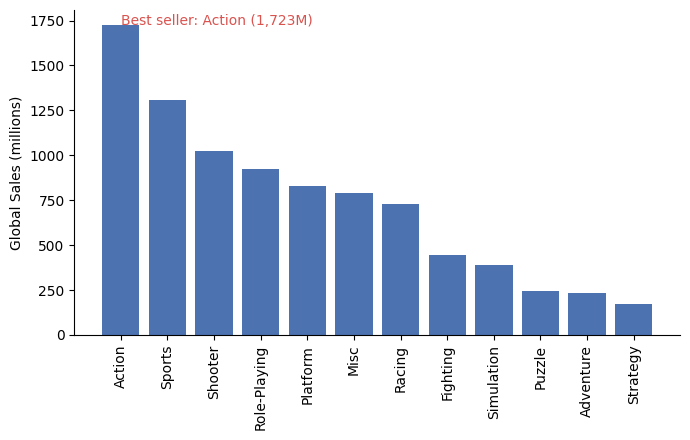

In [3]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
top_genre, top_value = genre_sales.index[0], genre_sales.iloc[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(genre_sales.index, genre_sales.values, color="#4C72B0")
ax.tick_params(axis="x", rotation=90)
ax.set_ylabel("Global Sales (millions)")

# TODO 1: replace the placeholder (x, y) below so the annotation sits directly above
# the tallest bar (top_genre / top_value), not in a random corner of the chart.
ax.annotate(f"Best seller: {top_genre} ({top_value:,.0f}M)",
            xy=(0, top_value), fontsize=10, color="#D9534F")

plt.tight_layout()
plt.show()

---
## Task 2 — Depth Cue: Texture Gradient

Meera wants a simple "shrinking toward the horizon" motif for the section-divider slide
— texture elements should get **smaller and more numerous** the farther they are from
the viewer, exactly like the lecture's tiled-floor example.

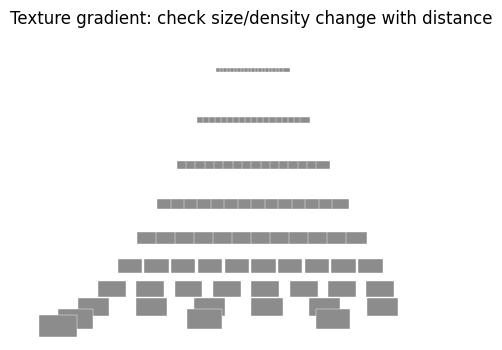

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
horizon = 1.0
n_rows = 10

for i in range(n_rows):
    frac = i / n_rows                      # 0 = far, 1 = near
    y = horizon * (1 - frac) ** 2

    # TODO 2a: size should get BIGGER as frac -> 1 (closer to viewer). Fix the formula.
    size = 0.03 + 0.15 * frac

    # TODO 2b: number of tiles should get SMALLER as frac -> 1 (fewer, bigger tiles up close).
    n_tiles = max(1, int(20 * (1 - frac)))

    for j in range(n_tiles):
        x = (j / n_tiles - 0.5) * (0.3 + 1.7 * frac)
        ax.add_patch(plt.Rectangle((x, y), size, size * 0.5, color="#8c8c8c", ec="white", lw=0.3))

ax.set_xlim(-1, 1); ax.set_ylim(0, 1.15)
ax.axis("off")
ax.set_title("Texture gradient: check size/density change with distance")
plt.show()

---
## Task 3 — Light & Shading

Meera: *"The flat gray circles on the title slide look like clip art. Add Lambertian
shading so they look like actual spheres."*

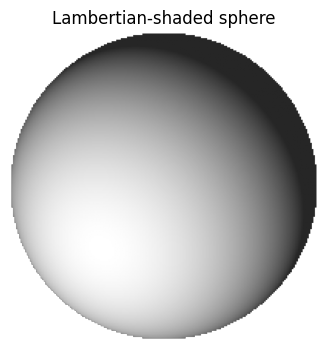

In [5]:
size = 200
yy, xx = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
r2 = xx**2 + yy**2
mask = r2 <= 1
z = np.sqrt(np.clip(1 - r2, 0, 1))

light_dir = np.array([-0.5, 0.5, 1.0])
light_dir = light_dir / np.linalg.norm(light_dir)

# TODO 3: compute Lambertian shading -- the dot product of the surface normal (xx, yy, z)
# with the light direction, then clip to [0, 1]. (Hint: normal = (xx, yy, z))
shade = np.clip(xx * light_dir[0] + yy * light_dir[1] + z * light_dir[2], 0, 1)

img = np.where(mask, 0.15 + 0.85 * shade, np.nan)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap="gray", vmin=0, vmax=1)
ax.axis("off")
ax.set_title("Lambertian-shaded sphere")
plt.show()

---
## Task 4 — Fix the Chart Junk

Meera's note: *"This pie chart has a shadow, a 3D-style bevel, no value labels, and an
arbitrary start angle. I can't even tell which genre is biggest at a glance. Redesign it
as a clean, labeled bar chart — remember the data-ink ratio principle from the lecture."*

Below is the **bad** chart (already built — just run it and look).
Then complete Task 4b to fix it.

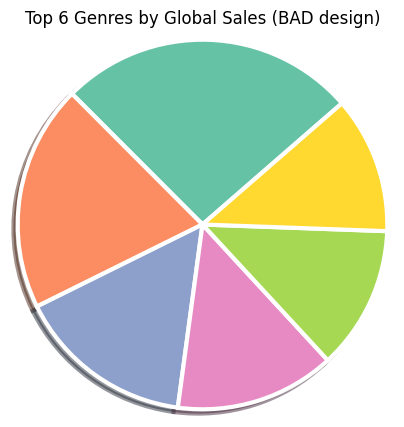

In [6]:
# BAD chart -- run this and see why Meera flagged it
genre_top6 = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(6)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(genre_top6.values, colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"],
       shadow=True, startangle=41, radius=1.2,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Top 6 Genres by Global Sales (BAD design)")
plt.show()

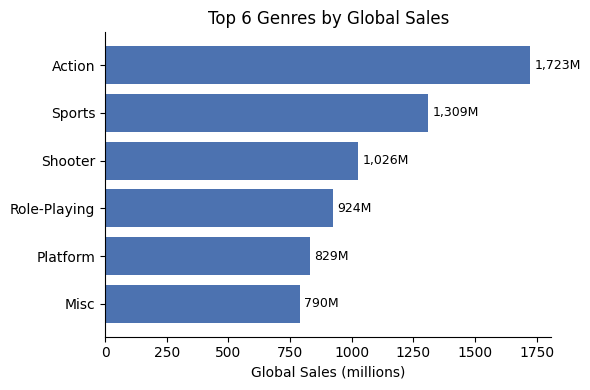

In [7]:
# TODO 4b: redesign as a GOOD graph -- a clean, labeled horizontal bar chart
# Requirements: sort ascending, label each bar with its exact value, clear title/axis label,
# no gridlines, no shadow, no 3D effect.

order = genre_top6.sort_values()  # ascending is correct: matplotlib draws the first
                                    # category at the bottom, so ascending order puts
                                    # the biggest genre at the top of a horizontal bar chart.

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(order.index, order.values, color="#4C72B0")   # plot 'order' as horizontal bars

# add a value label at the end of each bar
for bar, value in zip(bars, order.values):
    ax.text(bar.get_width() + order.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:,.0f}M", va="center", fontsize=9)

ax.set_xlabel("Global Sales (millions)")
ax.set_title("Top 6 Genres by Global Sales")
plt.tight_layout()
plt.show()

---
## Task 5 — Spot the Brightness Illusion

Meera: *"Build me a Hermann Grid for the 'perception matters' slide — you'll need a
grid of white squares on a black background so gray ghost-dots appear at the
intersections."*

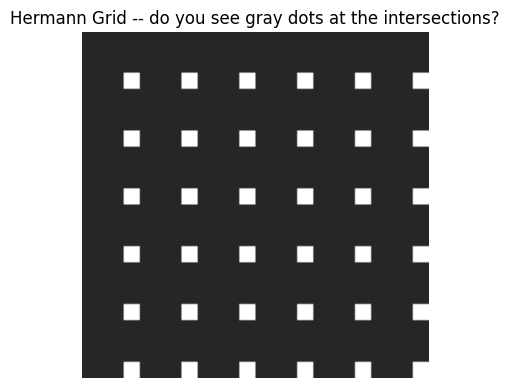

In [8]:
grid = np.ones((150, 150))

# TODO 5: for every 25-pixel step, set an 18-pixel-wide band to dark (0.15) both as a
# full ROW band and a full COLUMN band, so a grid pattern emerges (see the loop shape
# below -- just fill in the two slice assignments).
for i in range(0, 150, 25):
    grid[i:i+18, :] = 0.15   # dark row band
    grid[:, i:i+18] = 0.15   # dark column band

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(grid, cmap="gray", vmin=0, vmax=1)
ax.axis("off")
ax.set_title("Hermann Grid -- do you see gray dots at the intersections?")
plt.show()

---
## Task 6 — Enforce Proportional Ink

Meera's note: *"The average-sales-by-genre bar chart makes Puzzle games look like they
sell almost nothing compared to Platform games. Check the y-axis before you believe
that."*

Fix the bug below: the visual size of each bar must stay proportional to the actual
value it represents (zero baseline).

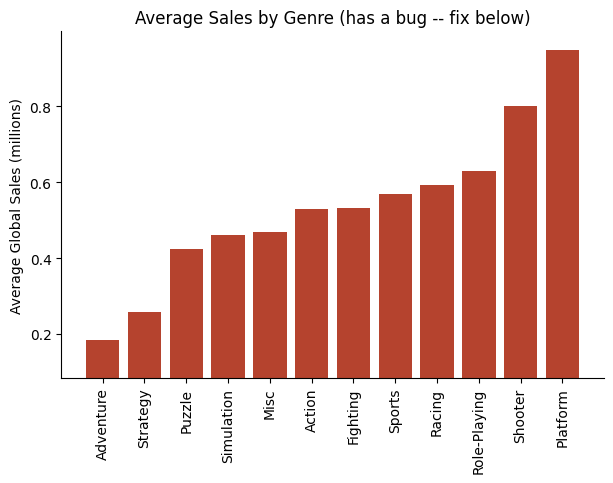

In [9]:
genre_avg = df.groupby("Genre")["Global_Sales"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(genre_avg.index, genre_avg.values, color="#b5432e")

# BUG: this truncated baseline is exactly what Meera flagged
ax.set_ylim(genre_avg.min() - 0.1, genre_avg.max() + 0.05)
ax.tick_params(axis="x", rotation=90)

ax.set_ylabel("Average Global Sales (millions)")
ax.set_title("Average Sales by Genre (has a bug -- fix below)")
plt.show()

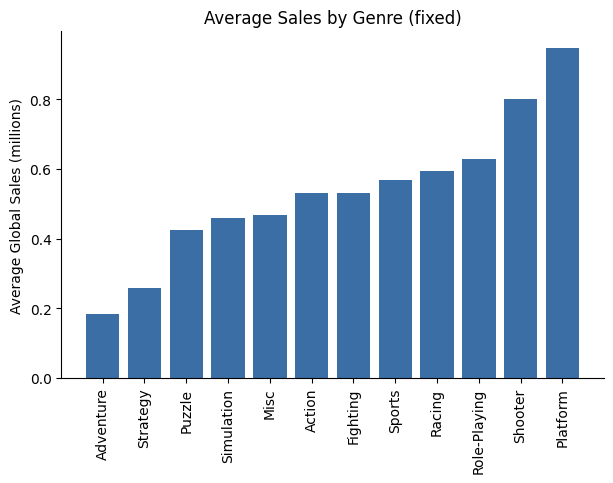

In [10]:
# TODO 6b: fix the proportional-ink violation above.
# Requirement: the y-axis must start at 0 so bar height honestly reflects the value.

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(genre_avg.index, genre_avg.values, color="#3b6ea5")

ax.set_ylim(0, genre_avg.max() * 1.05)   # zero baseline, 5% headroom above the max
ax.tick_params(axis="x", rotation=90)

ax.set_ylabel("Average Global Sales (millions)")
ax.set_title("Average Sales by Genre (fixed)")
plt.show()

# The highest-average genre (Platform, ~0.95M) actually outsells the lowest-average
# genre (Adventure, ~0.18M) by about 415% (roughly 5.1x), not the exaggerated gap
# the truncated-axis chart above made it look like.

---
## Task 7 — Log Scale: Points, Not Bars

Meera's note: *"Total sales by publisher is wildly skewed -- a few publishers dominate,
so a log axis makes sense. But don't use bars on a log axis, it lies about proportions.
Use a point plot instead."*

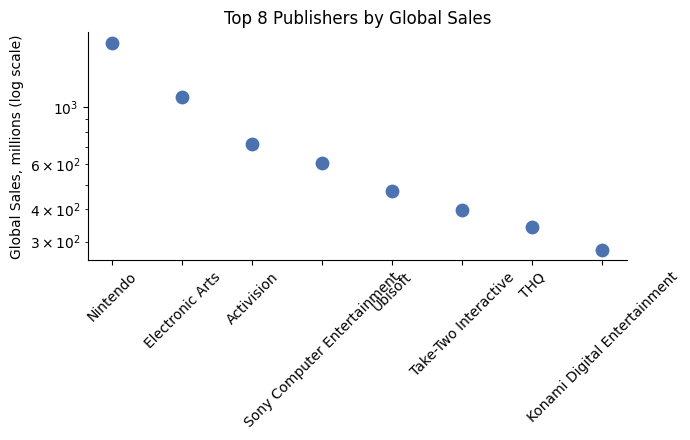

In [11]:
top_publishers = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(7, 4.5))

# TODO 7: plot top_publishers as a POINT plot (ax.scatter), not a bar chart
ax.scatter(top_publishers.index, top_publishers.values, color="#4C72B0", s=80, zorder=3)

ax.set_yscale("log")   # keep this -- the log axis itself is correct, only the mark type was wrong
ax.set_ylabel("Global Sales, millions (log scale)")
ax.set_title("Top 8 Publishers by Global Sales")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## Task 8 — Contrast Ratio Check
Meera: *"Marketing wants light-gray text on our cream slide background. Before you say
yes, calculate whether it actually clears the lecture's minimum 3:1 luminance contrast
guideline."*

In [12]:
def relative_luminance(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = lin(r), lin(g), lin(b)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(hex1, hex2):
    l1, l2 = relative_luminance(hex1), relative_luminance(hex2)
    lighter, darker = max(l1, l2), min(l1, l2)
    # TODO 8: implement the WCAG-style contrast ratio formula using 'lighter' and 'darker'
    return (lighter + 0.05) / (darker + 0.05)

text_color, bg_color = "#CCCCCC", "#F5F5DC"   # light-gray text on cream background
ratio = contrast_ratio(text_color, bg_color)
print(f"Contrast ratio: {ratio:.2f}")
print("Passes the 3:1 minimum?", "YES" if ratio >= 3 else "NO -- tell Marketing to pick a darker text color")

Contrast ratio: 1.45
Passes the 3:1 minimum? NO -- tell Marketing to pick a darker text color


---
## Reflection

Answer briefly in this markdown cell:

1. Of the eight fixes above, which one would have been the most misleading to leave
   un-fixed if it had gone in front of investors, and why?
2. In your own words, what is the **data-ink ratio**, and how did Task 4 change it?
3. Name one depth or motion cue from Tasks 2-3 and one brightness illusion from Task 5,
   and explain in a sentence each why a chart designer should care about them.
4. Complete the lecture's core idea: *"A visualization should make insight easier to
   __________, not harder to __________."*

**Your answers:**

1. Task 6's truncated y-axis on the average-sales-by-genre chart would have been the most misleading. It visually made Puzzle-style low-average genres look like they sell almost nothing next to Platform games, when the real gap is about 415% (roughly 5x), not the 10-20x it appeared to be -- investors could easily misjudge which genres are actually worth investing in.
2. The data-ink ratio is the proportion of a chart's total ink (or pixels) that actually represents data, versus decoration that carries no information. Task 4 raised this ratio by replacing a 3D pie chart with a shadow, bevel, and arbitrary start angle -- decoration that added zero informational value -- with a plain, flat, labeled bar chart where every mark corresponds directly to a real sales number.
3. From Task 2, texture gradient (tiles get bigger and sparser as they get closer to the viewer) is a depth cue -- a chart designer should care because the brain uses this cue automatically to judge distance/scale, so misusing element size can accidentally imply a depth or ranking that isn't there. From Task 5, the Hermann Grid illusion (gray ghost-dots appearing at white grid intersections on a black background) matters because it shows the visual system actively distorts brightness at high-contrast junctions -- so a chart designer should avoid dense grid lines or high-contrast crossing patterns that could create false visual artifacts.
4. A visualization should make insight easier to **see**, not harder to **find**.